# Week 12 CNN Challenge Laboratory

In [9]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage.io as skio
from skimage.transform import resize
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

np.random.seed(1)
tf.random.set_seed(1)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset Reading and Preprocessing

In [ ]:
IMAGE_SIZE = (54, 54)
INPUT_SHAPE = (54, 54, 3)
NUM_CLASSES = 2

# original data paths on Google Drive
DATA_ROOT = Path('/content/drive/MyDrive/BMET5933/AS1')
TRAIN_DATASET = DATA_ROOT / 'assign_train'
TEST_DATASET = DATA_ROOT / 'assign_test'
TRAIN_CSV = DATA_ROOT / 'training_data_ground_truth.csv'
TEST_CSV = DATA_ROOT / 'test_data_ground_truth.csv'

# move data to local for faster access
LOCAL_TRAIN_ROOT = Path('/content/BMET5933/AS1/assign_train')
LOCAL_TEST_ROOT = Path('/content/BMET5933/AS1/assign_test')


def read_label(csv_path):
    # Read case number and disease status from the ground truth csv file.
    df = pd.read_csv(csv_path)
    label_dict = dict(zip(df['case_number'].astype(str), df['disease_status'].astype(str)))
    return label_dict

def get_case_paths(label_dict, dataset_root):
    # Build image path and mask path for each case.
    case_paths = []
    for case_num in label_dict.keys():
        case_paths.append({
            'case_num': case_num,
            'img_path': dataset_root / f'{case_num}.jpg',
            'mask_path': dataset_root / f'{case_num}_Segmentation.png',
            'status': label_dict[case_num]
        })
    return case_paths


def make_two_class_mask(mask):
    # Channel 0 is background and channel 1 is foreground.
    foreground = (mask > 0).astype(np.float32)
    background = 1.0 - foreground
    two_class_mask = np.stack([background, foreground], axis=-1)
    return two_class_mask.astype(np.float32)


def read_one_sample(img_path, mask_path, image_size=IMAGE_SIZE):
    # Read and resize one image-mask pair.
    img = skio.imread(img_path)
    mask = skio.imread(mask_path)

    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    if img.shape[-1] == 4:
        img = img[:, :, :3]
    if mask.ndim == 3:
        mask = mask[:, :, 0]

    img = resize(img, image_size, preserve_range=True, anti_aliasing=True).astype(np.float32)
    mask = resize(mask, image_size, preserve_range=True, order=0, anti_aliasing=False)

    img = img / 255.0
    mask = make_two_class_mask(mask)
    return img, mask


def read_dataset(csv_path, dataset_root):
    # Read all images and masks from one dataset split.
    label_dict = read_label(csv_path)
    case_paths = get_case_paths(label_dict, dataset_root)

    images = []
    masks = []
    case_nums = []

    for item in case_paths:
        img, mask = read_one_sample(item['img_path'], item['mask_path'])
        images.append(img)
        masks.append(mask)
        case_nums.append(item['case_num'])

    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32), case_nums

In [ ]:
# Load Assignment 1 train and test data.
X_train_full, y_train_full, train_cases = read_dataset(TRAIN_CSV, LOCAL_TRAIN_ROOT)
X_test, y_test, test_cases = read_dataset(TEST_CSV, LOCAL_TEST_ROOT)

# Split part of the training set as validation data.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=1
)

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_val:', X_val.shape)
print('y_val:', y_val.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

X_train: (120, 54, 54, 3)
y_train: (120, 54, 54, 2)
X_val: (30, 54, 54, 3)
y_val: (30, 54, 54, 2)
X_test: (50, 54, 54, 3)
y_test: (50, 54, 54, 2)


## Keras U-Net Model

In [12]:
def conv_block(x, filters, block_name):
    # Each block follows Conv2D -> BatchNorm -> ReLU three times.
    for i in range(3):
        x = layers.Conv2D(
            filters=filters,
            kernel_size=3,
            padding='same',
            name=f'{block_name}_conv{i + 1}'
        )(x)
        x = layers.BatchNormalization(name=f'{block_name}_bn{i + 1}')(x)
        x = layers.ReLU(name=f'{block_name}_relu{i + 1}')(x)
    return x


def crop_to_match(source, target, name):
    # Crop the larger feature map so skip connection shapes match.
    source_h, source_w = int(source.shape[1]), int(source.shape[2])
    target_h, target_w = int(target.shape[1]), int(target.shape[2])

    if source_h > target_h or source_w > target_w:
        crop_h = source_h - target_h
        crop_w = source_w - target_w
        source = layers.Cropping2D(
            cropping=((crop_h // 2, crop_h - crop_h // 2), (crop_w // 2, crop_w - crop_w // 2)),
            name=f'{name}_crop_source'
        )(source)

    if target_h > source_h or target_w > source_w:
        crop_h = target_h - source_h
        crop_w = target_w - source_w
        target = layers.Cropping2D(
            cropping=((crop_h // 2, crop_h - crop_h // 2), (crop_w // 2, crop_w - crop_w // 2)),
            name=f'{name}_crop_target'
        )(target)

    return source, target


def make_unet_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape, name='input_image')

    # Encoder: 3 blocks.
    enc1 = conv_block(inputs, 64, 'encoder_block1')
    pool1 = layers.MaxPooling2D(pool_size=(2, 2), padding='same', name='pool1')(enc1)

    enc2 = conv_block(pool1, 128, 'encoder_block2')
    pool2 = layers.MaxPooling2D(pool_size=(2, 2), padding='same', name='pool2')(enc2)

    enc3 = conv_block(pool2, 256, 'encoder_block3')
    pool3 = layers.MaxPooling2D(pool_size=(2, 2), padding='same', name='pool3')(enc3)

    # Middle part of the U-Net.
    bridge = conv_block(pool3, 512, 'bridge_block')
    bridge = layers.Dropout(0.5, name='bridge_dropout')(bridge)

    # Decoder: 3 blocks with skip connections.
    up3 = layers.Conv2DTranspose(256, kernel_size=2, strides=2, padding='same', name='up3')(bridge)
    up3, enc3_crop = crop_to_match(up3, enc3, 'skip3')
    dec3 = layers.Concatenate(name='concat3')([up3, enc3_crop])
    dec3 = conv_block(dec3, 256, 'decoder_block3')

    up2 = layers.Conv2DTranspose(128, kernel_size=2, strides=2, padding='same', name='up2')(dec3)
    up2, enc2_crop = crop_to_match(up2, enc2, 'skip2')
    dec2 = layers.Concatenate(name='concat2')([up2, enc2_crop])
    dec2 = conv_block(dec2, 128, 'decoder_block2')

    up1 = layers.Conv2DTranspose(64, kernel_size=2, strides=2, padding='same', name='up1')(dec2)
    up1, enc1_crop = crop_to_match(up1, enc1, 'skip1')
    dec1 = layers.Concatenate(name='concat1')([up1, enc1_crop])
    dec1 = conv_block(dec1, 64, 'decoder_block1')

    outputs = layers.Conv2D(num_classes, kernel_size=1, activation='softmax', name='mask_output')(dec1)

    model = models.Model(inputs=inputs, outputs=outputs, name='three_block_unet')
    return model


model = make_unet_model()
model.summary()

Model: "three_block_unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 54, 54, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_con… │ (None, 54, 54,    │      1,792 │ input_image[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_bn1  │ (None, 54, 54,    │        256 │ encoder_block1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_rel… │ (None, 54, 54,    │          0 │ encoder_block1_b… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_con… │ (None, 54, 54,    │     36,928 │ encoder_block1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_bn2  │ (None, 54, 54,    │        256 │ encoder_block1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_rel… │ (None, 54, 54,    │          0 │ encoder_block1_b… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_con… │ (None, 54, 54,    │     36,928 │ encoder_block1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_bn3  │ (None, 54, 54,    │        256 │ encoder_block1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_rel… │ (None, 54, 54,    │          0 │ encoder_block1_b… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 27, 27,    │          0 │ encoder_block1_r… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_con… │ (None, 27, 27,    │     73,856 │ pool1[0][0]       │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_bn1  │ (None, 27, 27,    │        512 │ encoder_block2_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_rel… │ (None, 27, 27,    │          0 │ encoder_block2_b… │
│ (ReLU)              │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_con… │ (None, 27, 27,    │    147,584 │ encoder_block2_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_bn2  │ (None, 27, 27,    │        512 │ encoder_block2_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_rel… │ (None, 27, 27,    │          0 │ encoder_block2_b

 Total params: 11,623,298 (44.34 MB)

 Trainable params: 11,614,850 (44.31 MB)

 Non-trainable params: 8,448 (33.00 KB)

## Training

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=4
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 32s 151ms/step - accuracy: 0.7838 - loss: 0.5550 - val_accuracy: 0.5457 - val_loss: 1.0410
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8416 - loss: 0.3996 - val_accuracy: 0.2733 - val_loss: 136.8709
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8533 - loss: 0.3726 - val_accuracy: 0.4635 - val_loss: 11.8490
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8682 - loss: 0.3373 - val_accuracy: 0.7271 - val_loss: 0.5550
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8688 - loss: 0.3214 - val_accuracy: 0.7473 - val_loss: 0.5526
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8823 - loss: 0.2926 - val_accuracy: 0.7328 - val_loss: 1.5791
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8865 - loss: 0.2848 - val_accuracy: 0.7907 - val_loss: 0.4975
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8897 - loss: 0.2834 - val_accuracy: 0.838

## Evaluation and Prediction Display

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.7241 - loss: 1.0106
Test result: {'loss': 1.0105911493301392, 'compile_metrics': 0.724067211151123}
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step
Foreground IoU: 0.27113792416254506


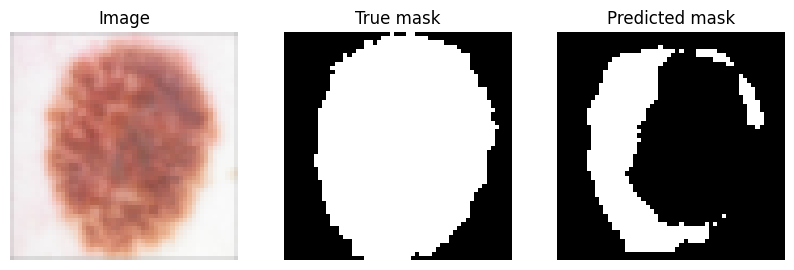

In [14]:
test_result = model.evaluate(X_test, y_test)
print('Test result:', dict(zip(model.metrics_names, test_result)))

pred_masks = model.predict(X_test)
pred_labels = np.argmax(pred_masks, axis=-1)
true_labels = np.argmax(y_test, axis=-1)


def calculate_foreground_iou(pred_labels, true_labels):
    # Calculate IoU for the foreground class only.
    pred_foreground = pred_labels == 1
    true_foreground = true_labels == 1
    intersection = np.logical_and(pred_foreground, true_foreground).sum()
    union = np.logical_or(pred_foreground, true_foreground).sum()
    return intersection / union


foreground_iou = calculate_foreground_iou(pred_labels, true_labels)
print('Foreground IoU:', foreground_iou)


def show_prediction(index=0):
    # Display original image, true mask, and predicted mask.
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    axes[0].imshow(X_test[index])
    axes[0].set_title('Image')
    axes[0].axis('off')

    axes[1].imshow(true_labels[index], cmap='gray')
    axes[1].set_title('True mask')
    axes[1].axis('off')

    axes[2].imshow(pred_labels[index], cmap='gray')
    axes[2].set_title('Predicted mask')
    axes[2].axis('off')

    plt.show()


show_prediction(0)

## Export Notebook to PDF

In [15]:
# Run this cell after all previous cells finish successfully.
# !apt-get update
# !sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
!jupyter nbconvert --to pdf /content/colab/MyDrive/BMET5933/WEEK_12/WEEK_12.ipynb

[NbConvertApp] WARNING | pattern '/content/colab/MyDrive/BMET5933/WEEK_12/WEEK_12.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--Jupyt